# Data & Feature Validation

Sanity checks for the raw manifest, feature tables, and the `selected_token` / `max_samples_per_class` pipeline.

**Checks covered:**
1. Manifest integrity: missing values, WAV conversion status, token coverage
2. Feature tables: shape, NaN rates, status columns, join integrity
3. Per-class / per-speaker distribution before and after filtering
4. Selected token pipeline: verifies token filtering + class capping work correctly
5. Feature value sanity: ranges, correlations, obvious anomalies

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append("..")
from src.features import FeatureOptions, load_feature_tables

## 1. Raw Manifest Integrity

In [2]:
manifest = pd.read_csv(Path("..") / "data" / "processed" / "manifests" / "dataset_manifest.csv")
print(f"Manifest shape: {manifest.shape}")
print(f"Columns: {list(manifest.columns)}")
print()

# Missing values
missing = manifest.isnull().sum()
missing_pct = (missing / len(manifest) * 100).round(1)
missing_report = pd.DataFrame({"missing": missing, "pct": missing_pct})
print("=== Columns with missing values ===")
display(missing_report[missing_report["missing"] > 0])

# WAV conversion status
print("\n=== WAV conversion status ===")
print(manifest["wav_conversion_status"].value_counts())

# Duplicate sample keys?
n_dupes = manifest["sample_key"].duplicated().sum()
print(f"\nDuplicate sample_keys: {n_dupes}")
assert n_dupes == 0, "DUPLICATE SAMPLE KEYS FOUND!"

Manifest shape: (15267, 31)
Columns: ['sample_key', 'duplicate_class_key', 'recording_id', 'speaker_id', 'is_overlap_speaker', 'is_overlap_speaker_id', 'recording_type', 'recording_date', 'birth_date', 'sex', 'diagnosis_de', 'pathology_de', 'pathology_en', 'pathology_csv_raw', 'is_healthy', 'modality', 'token', 'nsp_path', 'wav_path', 'egg_path', 'has_egg', 'remarks_path', 'has_remarks', 'recording_dir', 'overview_path', 'overview_match_status', 'wav_conversion_status', 'wav_sample_rate', 'wav_num_frames', 'wav_num_channels', 'wav_error']

=== Columns with missing values ===


,missing,pct
diagnosis_de,9859,64.6
pathology_csv_raw,9565,62.7
remarks_path,10671,69.9
wav_error,15267,100.0



=== WAV conversion status ===
wav_conversion_status
converted    15267
Name: count, dtype: int64

Duplicate sample_keys: 0


In [3]:
# Per-pathology breakdown
patho_summary = manifest.groupby("pathology_de").agg(
    total_samples=("sample_key", "count"),
    unique_recordings=("recording_id", "nunique"),
    unique_speakers=("speaker_id", "nunique"),
    unique_tokens=("token", "nunique"),
    modalities=("modality", lambda x: sorted(x.unique().tolist())),
).sort_values("total_samples", ascending=False)

patho_summary["samples_per_speaker"] = (patho_summary["total_samples"] / patho_summary["unique_speakers"]).round(1)

print("=== Per-pathology manifest breakdown ===")
display(patho_summary)

=== Per-pathology manifest breakdown ===


,total_samples,unique_recordings,unique_speakers,unique_tokens,modalities,samples_per_speaker
pathology_de,,,,,,
healthy,9565,687,681,14,"[sentences, vowels]",14.0
Rekurrensparese,2973,213,156,14,"[sentences, vowels]",19.1
Reinke Ödem,952,68,54,14,"[sentences, vowels]",17.6
Spasmodische Dysphonie,896,64,12,14,"[sentences, vowels]",74.7
Stimmlippenpolyp,630,45,40,14,"[sentences, vowels]",15.8
Phonationsknötchen,237,17,17,14,"[sentences, vowels]",13.9
Morbus Parkinson,14,1,1,14,"[sentences, vowels]",14.0


In [4]:
# Token coverage: does every speaker have every token?
token_pivot = manifest.groupby(["pathology_de", "token"]).agg(
    n_speakers=("speaker_id", "nunique")
).reset_index().pivot(index="pathology_de", columns="token", values="n_speakers").fillna(0).astype(int)

print("=== Speakers per token per pathology ===")
display(token_pivot)

# Highlight: which tokens have the most complete coverage?
token_totals = token_pivot.sum(axis=0).sort_values(ascending=False)
print("\n=== Total speakers per token (all pathologies) ===")
print(token_totals)

=== Speakers per token per pathology ===


token,a_h,a_l,a_lhl,a_n,i_h,i_l,i_lhl,i_n,iau,phrase,u_h,u_l,u_lhl,u_n
pathology_de,,,,,,,,,,,,,,
Morbus Parkinson,1,1,1,1,1,1,1,1,1,1,1,1,1,1
Phonationsknötchen,17,17,17,17,17,17,17,17,17,16,17,17,17,17
Reinke Ödem,54,54,54,54,54,54,54,54,54,54,54,54,54,54
Rekurrensparese,156,155,154,156,156,155,154,156,156,156,156,155,154,156
Spasmodische Dysphonie,12,12,12,12,12,12,12,12,12,12,12,12,12,12
Stimmlippenpolyp,40,40,40,40,40,40,40,40,40,40,40,40,40,40
healthy,681,681,681,681,681,681,681,681,681,630,681,681,681,681



=== Total speakers per token (all pathologies) ===
token
a_h       961
a_n       961
i_h       961
u_n       961
iau       961
i_n       961
u_h       961
u_l       960
a_l       960
i_l       960
a_lhl     959
i_lhl     959
u_lhl     959
phrase    909
dtype: int64


## 2. Feature Table Integrity

In [5]:
# Load existing cached feature tables (no extraction)
opts_full = FeatureOptions(
    prefix=Path(".."),
    include_splits=True,
)

tables = load_feature_tables(options=opts_full, build_if_missing=False)

for name, tbl in tables.items():
    print(f"{name:15s}  shape={str(tbl.shape):15s}  sample_keys={tbl['sample_key'].nunique() if 'sample_key' in tbl.columns else 'N/A'}")

core             shape=(595, 18)        sample_keys=595
acoustic         shape=(595, 87)        sample_keys=595
multifractal     shape=(595, 17)        sample_keys=595
opensmile        shape=(595, 91)        sample_keys=595
splits           shape=(595, 3)         sample_keys=595


In [6]:
core_df = tables["core"]
acoustic_df = tables["acoustic"]
mf_df = tables["multifractal"]
os_df = tables["opensmile"]

# Check join integrity: do all tables have the same sample_keys?
core_keys = set(core_df["sample_key"])
acoustic_keys = set(acoustic_df["sample_key"])
mf_keys = set(mf_df["sample_key"])
os_keys = set(os_df["sample_key"])

print(f"Core keys:       {len(core_keys)}")
print(f"Acoustic keys:   {len(acoustic_keys)}  (missing from core: {len(acoustic_keys - core_keys)})")
print(f"Multifractal keys: {len(mf_keys)}  (missing from core: {len(mf_keys - core_keys)})")
print(f"OpenSMILE keys:  {len(os_keys)}  (missing from core: {len(os_keys - core_keys)})")

all_match = (core_keys == acoustic_keys == mf_keys == os_keys)
print(f"\nAll tables have identical sample_keys: {all_match}")
if not all_match:
    print("  Core - Acoustic:", core_keys - acoustic_keys)
    print("  Core - MF:", core_keys - mf_keys)
    print("  Core - OS:", core_keys - os_keys)

Core keys:       595
Acoustic keys:   595  (missing from core: 0)
Multifractal keys: 595  (missing from core: 0)
OpenSMILE keys:  595  (missing from core: 0)

All tables have identical sample_keys: True


In [7]:
# Status columns — how many samples succeeded vs failed?
print("=== Feature extraction status ===")
if "feature_status" in core_df.columns:
    print("\nCore feature_status:")
    print(core_df["feature_status"].value_counts())

if "acoustic_status" in acoustic_df.columns:
    print("\nAcoustic status:")
    print(acoustic_df["acoustic_status"].value_counts())

if "mf_status" in mf_df.columns:
    print("\nMultifractal status:")
    print(mf_df["mf_status"].value_counts())

if "opensmile_status" in os_df.columns:
    print("\nOpenSMILE status:")
    print(os_df["opensmile_status"].value_counts())

=== Feature extraction status ===

Core feature_status:
feature_status
ok    595
Name: count, dtype: int64

Acoustic status:
acoustic_status
ok    595
Name: count, dtype: int64

Multifractal status:
mf_status
ok    595
Name: count, dtype: int64

OpenSMILE status:
opensmile_status
ok    595
Name: count, dtype: int64


In [8]:
# NaN rates in numeric feature columns
def nan_report(df, name):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    nan_counts = df[numeric_cols].isnull().sum()
    nan_pct = (nan_counts / len(df) * 100).round(1)
    report = pd.DataFrame({"nan_count": nan_counts, "nan_pct": nan_pct})
    report = report[report["nan_count"] > 0].sort_values("nan_pct", ascending=False)
    if report.empty:
        print(f"{name}: No NaN values in {len(numeric_cols)} numeric columns ✓")
    else:
        print(f"\n{name}: {len(report)} columns with NaNs (out of {len(numeric_cols)})")
        display(report)

nan_report(acoustic_df, "Acoustic")
nan_report(mf_df, "Multifractal")
nan_report(os_df, "OpenSMILE")


Acoustic: 1 columns with NaNs (out of 85)


,nan_count,nan_pct
acoustic_error,595,100.0



Multifractal: 1 columns with NaNs (out of 15)


,nan_count,nan_pct
mf_error,595,100.0



OpenSMILE: 1 columns with NaNs (out of 89)


,nan_count,nan_pct
opensmile_error,595,100.0


## 3. Feature Value Sanity

In [9]:
# Merge core + features for OK samples only
ok_mask = core_df["feature_status"].isin(["ok", "partial_failure"])
core_ok = core_df[ok_mask].copy()

merged = core_ok.merge(acoustic_df, on="sample_key", how="left")
merged = merged.merge(mf_df, on="sample_key", how="left")
merged = merged.merge(os_df, on="sample_key", how="left")

# Pick key features and check ranges
key_features = [
    "ac_f0_mean", "ac_f0_std",
    "ac_rms_mean", "ac_zcr_mean",
    "ac_mfcc1_mean", "ac_mfcc2_mean",
    "mf_hq_mean", "mf_spectrum_width", "mf_spectrum_asymmetry",
    "audio_duration_seconds",
]
available_features = [f for f in key_features if f in merged.columns]

print("=== Key feature statistics (OK samples only) ===")
display(merged[available_features].describe().round(3))

=== Key feature statistics (OK samples only) ===


,ac_f0_mean,ac_f0_std,ac_rms_mean,ac_zcr_mean,ac_mfcc1_mean,ac_mfcc2_mean,mf_hq_mean,mf_spectrum_width,mf_spectrum_asymmetry,audio_duration_seconds
count,595.000,595.000,595.000,595.000,595.000,595.000,595.000,595.000,595.000,595.000
mean,195.783,21.452,0.284,0.024,-190.093,196.392,0.604,0.675,0.350,1.268
std,106.546,58.383,0.068,0.012,38.357,29.375,0.119,0.156,0.325,0.474
min,81.520,0.412,0.097,0.004,-285.319,73.431,0.289,0.189,0.073,0.393
25%,134.198,1.506,0.235,0.019,-216.258,176.513,0.527,0.568,0.236,0.894
50%,191.708,2.551,0.285,0.023,-194.033,193.081,0.600,0.669,0.272,1.252
75%,229.060,10.347,0.331,0.028,-170.370,215.658,0.676,0.774,0.321,1.635
max,1425.897,524.510,0.534,0.165,-40.165,267.977,1.006,1.197,2.201,4.390


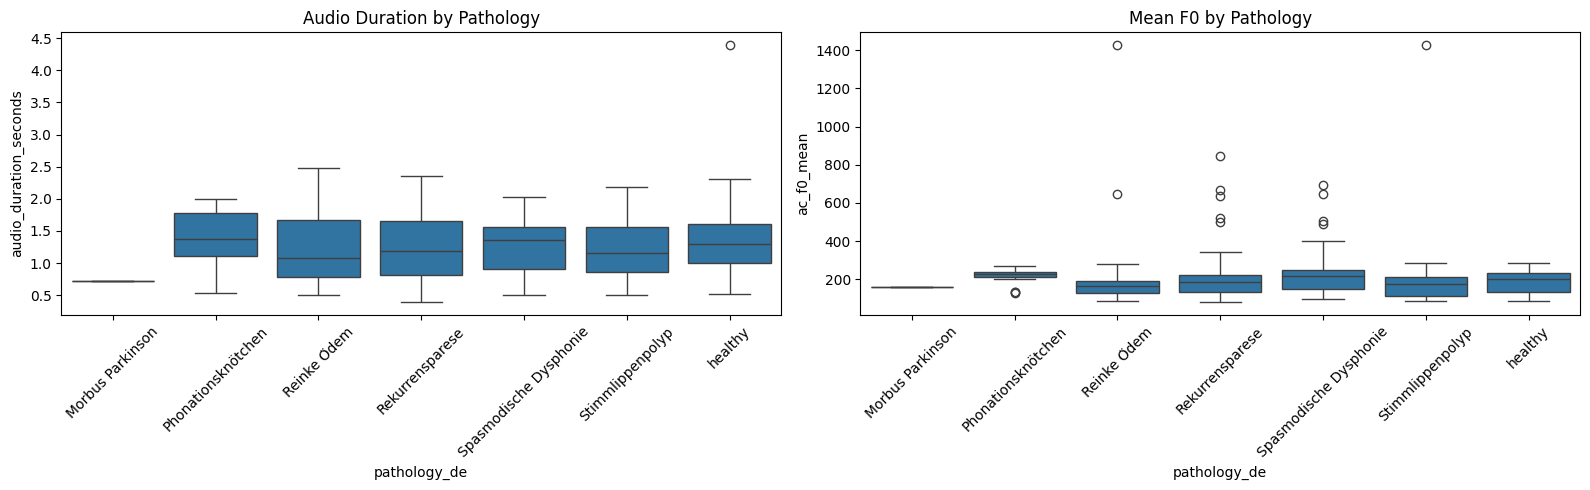

In [10]:
# Distribution of audio durations by pathology
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=merged, x="pathology_de", y="audio_duration_seconds", ax=axes[0])
axes[0].set_title("Audio Duration by Pathology")
axes[0].tick_params(axis="x", rotation=45)

if "ac_f0_mean" in merged.columns:
    sns.boxplot(data=merged, x="pathology_de", y="ac_f0_mean", ax=axes[1])
    axes[1].set_title("Mean F0 by Pathology")
    axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Check for infinite values in numeric feature columns only
feature_cols = [c for c in merged.columns if c.startswith(("ac_", "mf_", "os_"))]
numeric_feature_cols = merged[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

inf_counts = merged[numeric_feature_cols].apply(lambda x: np.isinf(x).sum())
inf_nonzero = inf_counts[inf_counts > 0]

if inf_nonzero.empty:
    print(f"No infinite values in {len(numeric_feature_cols)} numeric feature columns ✓")
else:
    print(f"WARNING: {len(inf_nonzero)} columns contain infinite values:")
    display(inf_nonzero)

No infinite values in 187 numeric feature columns ✓


## 4. Selected Token Pipeline Validation

In [12]:
# Validate that selected_token + max_samples_per_class pipeline works correctly
from src.features.feature_extraction import _prepare_target_manifest

SELECTED_TOKEN = "a_n"
MAX_SAMPLES = 200
MIN_SAMPLES = 10

opts_token = FeatureOptions(
    prefix=Path(".."),
    selected_token=SELECTED_TOKEN,
    max_samples_per_class=MAX_SAMPLES,
)

filtered_manifest = _prepare_target_manifest(opts_token)

print(f"=== Pipeline output: selected_token='{SELECTED_TOKEN}', max_samples_per_class={MAX_SAMPLES} ===")
print(f"Total samples: {len(filtered_manifest)}")
print(f"Unique tokens: {filtered_manifest['token'].unique().tolist()}")
assert filtered_manifest['token'].nunique() == 1, f"Expected 1 token, got {filtered_manifest['token'].nunique()}"
assert (filtered_manifest['token'] == SELECTED_TOKEN).all(), "Token filter failed!"
print("Token filter: ✓")
print()

# Per-class counts
class_counts = filtered_manifest.groupby("pathology_de").agg(
    samples=("sample_key", "count"),
    speakers=("speaker_id", "nunique"),
).sort_values("samples", ascending=False)

class_counts["capped"] = class_counts["samples"] == MAX_SAMPLES

display(class_counts)

# Verify no class exceeds the cap
assert (class_counts["samples"] <= MAX_SAMPLES).all(), "MAX_SAMPLES_PER_CLASS violated!"
print(f"\nMax samples per class cap ({MAX_SAMPLES}): ✓")

# Flag classes below MIN_SAMPLES
small = class_counts[class_counts["samples"] < MIN_SAMPLES]
if not small.empty:
    print(f"\nClasses below MIN_SAMPLES_PER_CLASS ({MIN_SAMPLES}):")
    display(small)
else:
    print(f"All classes >= {MIN_SAMPLES} samples: ✓")

=== Pipeline output: selected_token='a_n', max_samples_per_class=200 ===
Total samples: 595
Unique tokens: ['a_n']
Token filter: ✓



,samples,speakers,capped
pathology_de,,,
Rekurrensparese,200,149,True
healthy,200,200,True
Reinke Ödem,68,54,False
Spasmodische Dysphonie,64,12,False
Stimmlippenpolyp,45,40,False
Phonationsknötchen,17,17,False
Morbus Parkinson,1,1,False



Max samples per class cap (200): ✓

Classes below MIN_SAMPLES_PER_CLASS (10):


,samples,speakers,capped
pathology_de,,,
Morbus Parkinson,1,1,False


In [13]:
# Verify 1 sample per speaker for the selected token
samples_per_speaker = filtered_manifest.groupby(["pathology_de", "speaker_id"]).size()
multi_sample_speakers = samples_per_speaker[samples_per_speaker > 1]

if multi_sample_speakers.empty:
    print(f"Each speaker has exactly 1 '{SELECTED_TOKEN}' sample: ✓")
else:
    print(f"WARNING: {len(multi_sample_speakers)} speakers have >1 sample for '{SELECTED_TOKEN}':")
    display(multi_sample_speakers.head(20))
    print("This could indicate duplicate recordings per speaker for the same token.")

pathology_de     speaker_id
Reinke Ödem     1340          2
                 1386          2
                 1541          2
                 1617          3
                 1733          2
                 1966          2
                 2001          2
                 2078          5
                 2358          3
Rekurrensparese  1305          3
                 1313          2
                 1350          2
                 1357          2
                 1385          3
                 1386          2
                 1397          2
                 1398          2
                 1419          3
                 1448          6
                 1477          2
dtype: int64

This could indicate duplicate recordings per speaker for the same token.


## 5. Speaker Overlap Check

In [14]:
# Check if any speakers appear in multiple pathology classes
speaker_classes = manifest.groupby("speaker_id")["pathology_de"].nunique()
overlap_speakers = speaker_classes[speaker_classes > 1]

if overlap_speakers.empty:
    print("No speakers appear in multiple pathology classes: ✓")
else:
    print(f"WARNING: {len(overlap_speakers)} speakers appear in multiple classes:")
    for sid in overlap_speakers.index[:10]:
        classes = manifest[manifest["speaker_id"] == sid]["pathology_de"].unique()
        print(f"  Speaker {sid}: {classes.tolist()}")

# Check is_overlap_speaker flag consistency
if "is_overlap_speaker_id" in manifest.columns:
    flagged = manifest["is_overlap_speaker_id"].sum()
    print(f"\nSamples flagged as overlap speakers: {flagged}")

  Speaker 74: ['healthy', 'Rekurrensparese']
  Speaker 142: ['healthy', 'Reinke Ödem']
  Speaker 1317: ['Phonationsknötchen', 'Stimmlippenpolyp']
  Speaker 1383: ['Reinke Ödem', 'Rekurrensparese']
  Speaker 1386: ['Reinke Ödem', 'Rekurrensparese']
  Speaker 1389: ['Reinke Ödem', 'Rekurrensparese']
  Speaker 1412: ['Reinke Ödem', 'Stimmlippenpolyp']
  Speaker 1459: ['Rekurrensparese', 'Stimmlippenpolyp']
  Speaker 1494: ['Reinke Ödem', 'Spasmodische Dysphonie']
  Speaker 1524: ['healthy', 'Stimmlippenpolyp']

Samples flagged as overlap speakers: 630


## 6. Feature Correlation Heatmap (Top Features)

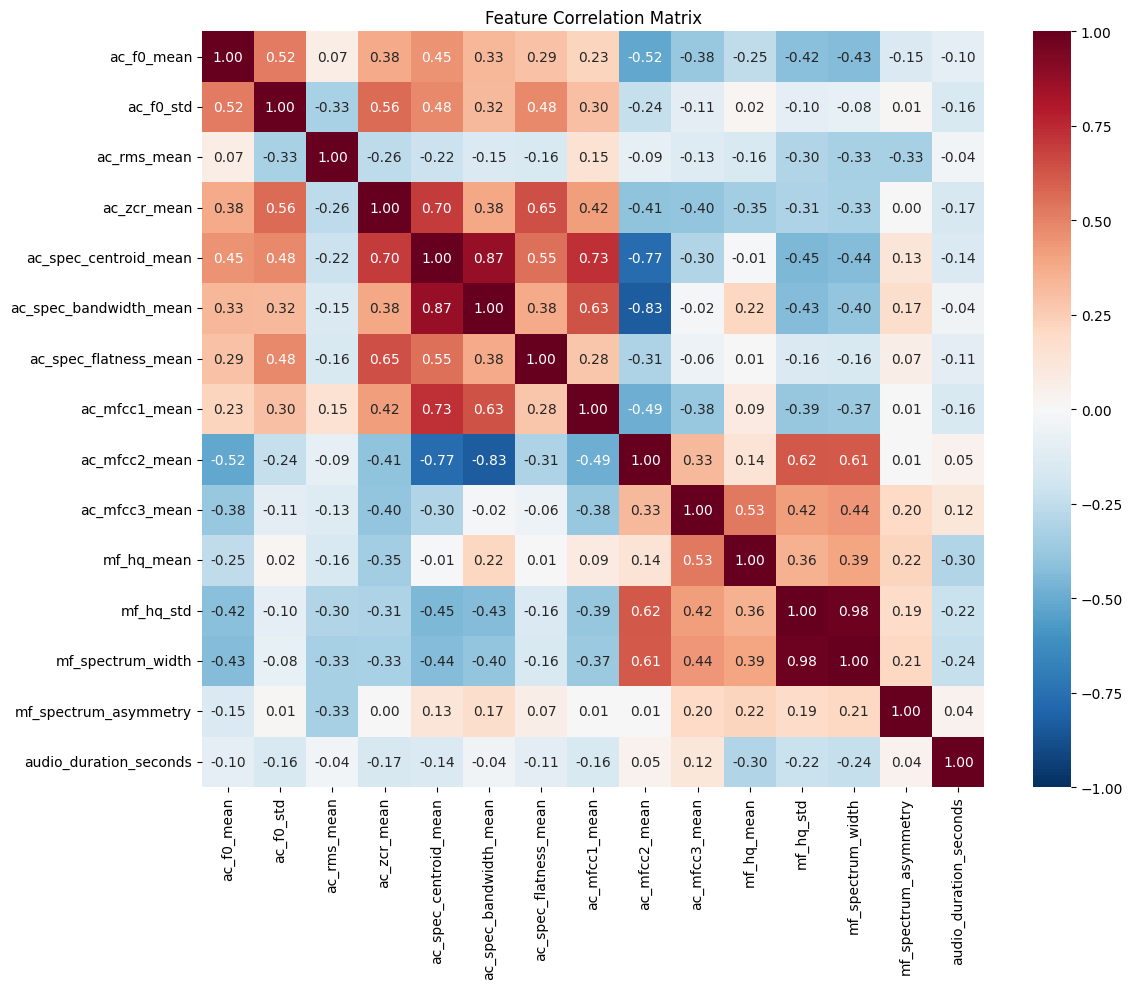

In [15]:
# Correlation among key acoustic + multifractal features
corr_features = [
    "ac_f0_mean", "ac_f0_std", "ac_rms_mean", "ac_zcr_mean",
    "ac_spec_centroid_mean", "ac_spec_bandwidth_mean", "ac_spec_flatness_mean",
    "ac_mfcc1_mean", "ac_mfcc2_mean", "ac_mfcc3_mean",
    "mf_hq_mean", "mf_hq_std", "mf_spectrum_width", "mf_spectrum_asymmetry",
    "audio_duration_seconds",
]
avail = [f for f in corr_features if f in merged.columns]

corr = merged[avail].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Summary

If all assertions passed above, the data pipeline is consistent:
- Manifest has no duplicate keys
- All feature tables share the same sample keys
- Token filtering works correctly at the manifest level
- `max_samples_per_class` caps are respected
- No infinite values in features
- Speaker overlap is flagged